# 05 — Segmentation client Olist (Phase 6)

Ce notebook execute le pipeline de segmentation (`src/models/segmentation.py`) sur `data/processed/olist_features_scaled.csv` (93 358 clients, produit par la Phase 5).

**Objectif** : regrouper les clients en segments actionnables pour le marketing, a partir de 5 features normalisees : `recency_scaled`, `frequency_scaled`, `monetary_scaled`, `tenure_scaled`, `review_scaled`.

**Algorithmes compares** : K-Means (algo principal, k=4), DBSCAN (detection de bruit/densite) et clustering hierarchique (validation sur echantillon).

## 1. Chargement des donnees

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Le notebook est exécuté depuis notebooks/, donc la racine du projet est le
# dossier parent. On l'ajoute à sys.path pour pouvoir importer src.models comme
# un package, exactement comme le fait segmentation.py.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eda.analysis import DEFAULT_COLOR
from src.features.feature_report import load_features
from src.models import segmentation

scaled_df = segmentation.load_features_scaled()
X = scaled_df[segmentation.CLUSTERING_FEATURES].values
print("Shape :", scaled_df.shape)
scaled_df.head()

Shape : (93358, 7)


,customer_unique_id,churn,recency_scaled,frequency_scaled,monetary_scaled,tenure_scaled,review_scaled
0,0000366f3b9a7992bf8c76cfdf3221e2,0,-0.825357,-0.159829,0.162904,-0.105548,0.658041
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,-0.805697,-0.159829,-1.623560,-0.105548,-0.124462
2,0000f46a3911fa3c0805444483337064,1,1.959873,-0.159829,-0.380473,-0.105548,-0.906964
3,0000f6ccb0745a6a4b88665a16c9f078,1,0.544321,-0.159829,-1.118150,-0.105548,-0.124462
4,0004aac84e0df4da2b147fca70cf8255,1,0.328056,-0.159829,0.521221,-0.105548,0.658041


## 2. Determination du k optimal (elbow + silhouette)

[ETAPE 1] Meilleur k selon silhouette score : 2 (score=0.6915)
[ETAPE 1] Graphique sauvegarde dans C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\docs\elbow_silhouette.png


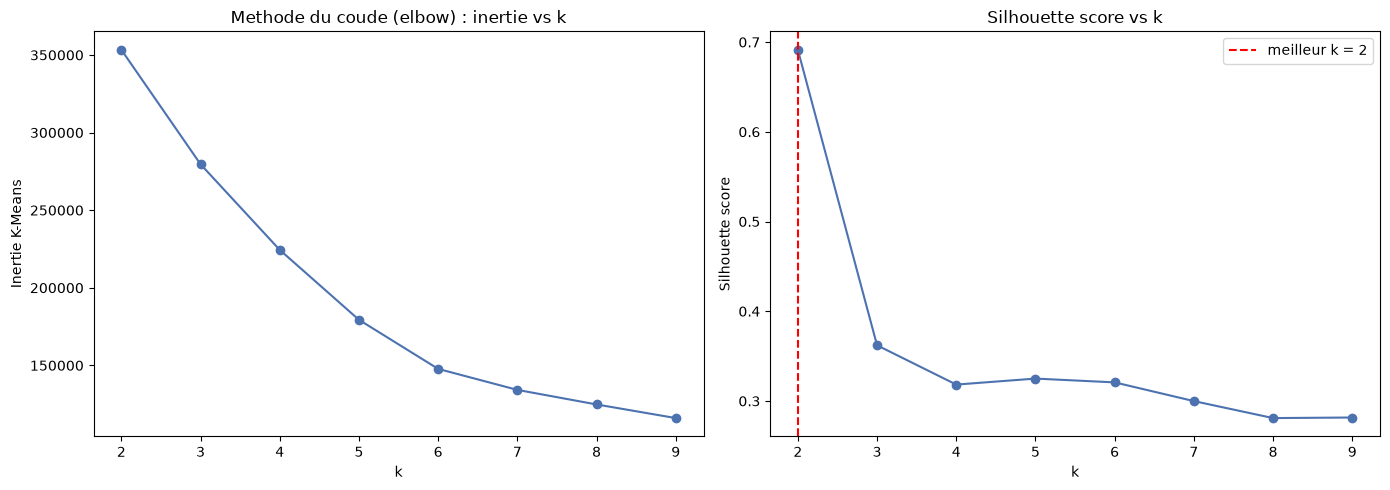

Meilleur k (silhouette) : 2 (score=0.6915)


In [2]:
best_k, best_k_score, fig = segmentation.find_optimal_k(X)
plt.show()
print(f"Meilleur k (silhouette) : {best_k} (score={best_k_score:.4f})")

## 3. Entrainement K-Means (k=4)

In [3]:
model, labels = segmentation.train_kmeans(X)
scaled_df["segment"] = labels
scaled_df["segment"].value_counts().sort_index()

[ETAPE 2] K-Means entraine avec k=4
[ETAPE 2] Distribution des segments :
0    42893
1    32407
2     2801
3    15257
[ETAPE 2] Modele sauvegarde dans C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\models\kmeans_model.pkl


segment
0    42893
1    32407
2     2801
3    15257
Name: count, dtype: int64

## 4. Interpretation et nommage des segments

In [4]:
full_df = load_features()
merged_df = full_df.merge(scaled_df[["customer_unique_id", "segment"]], on="customer_unique_id", how="inner")
merged_df = segmentation.interpret_segments(merged_df)

merged_df.groupby("segment_name")[segmentation.RAW_PROFILE_FEATURES + ["rfm_score"]].mean()

[ETAPE 3] Profils moyens par segment (tries par rfm_score decroissant) :
         recency_days  frequency  total_spent  avg_review_score  customer_tenure_days  rfm_score  count segment_name
segment                                                                                                             
2          219.294538   2.113888   486.380582          4.206403             87.792931   3.378198   2801    Champions
0          122.815728   1.000000   179.114209          4.684109              0.000000   2.729793  42893      Fideles
3          230.781019   1.000000   308.692599          1.665563              0.000000   2.576959  15257     A Risque
1          392.421545   1.000000   189.072091          4.633937              0.000000   2.086288  32407       Perdus


,recency_days,frequency,total_spent,avg_review_score,customer_tenure_days,rfm_score
segment_name,,,,,,
A Risque,230.781019,1.000000,308.692599,1.665563,0.000000,2.576959
Champions,219.294538,2.113888,486.380582,4.206403,87.792931,3.378198
Fideles,122.815728,1.000000,179.114209,4.684109,0.000000,2.729793
Perdus,392.421545,1.000000,189.072091,4.633937,0.000000,2.086288


## 5. Scatter plot 2D : recency_scaled vs monetary_scaled, colore par segment

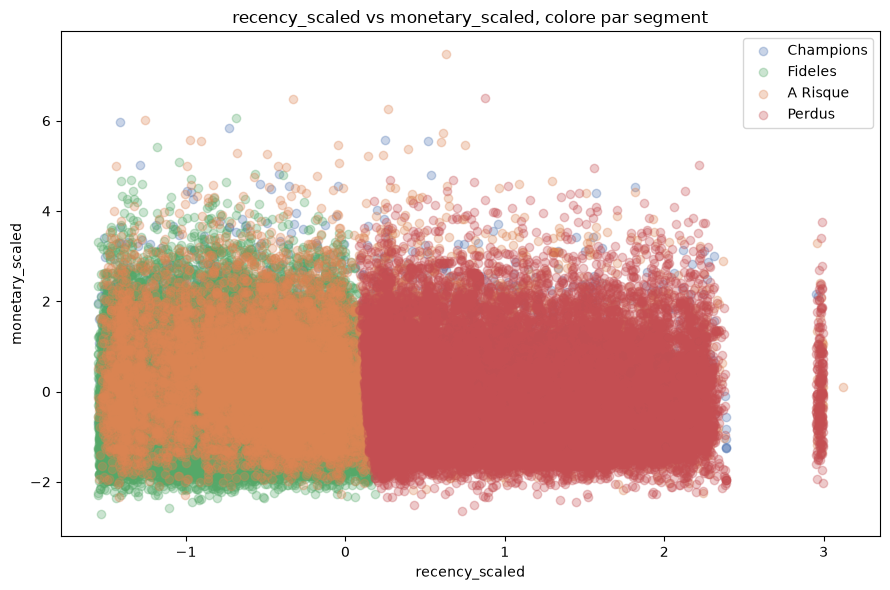

In [5]:
segment_colors = {"Champions": "#4C72B0", "Fideles": "#55A868", "A Risque": "#DD8452", "Perdus": "#C44E52"}

fig, ax = plt.subplots(figsize=(9, 6))
for segment_name, color in segment_colors.items():
    subset = merged_df[merged_df["segment_name"] == segment_name]
    ax.scatter(subset["recency_scaled"], subset["monetary_scaled"], alpha=0.3, color=color, label=segment_name)
ax.set_title("recency_scaled vs monetary_scaled, colore par segment")
ax.set_xlabel("recency_scaled")
ax.set_ylabel("monetary_scaled")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Profils moyens des 4 segments (features brutes)

Petits multiples (un graphique par feature) plutot qu'un seul graphique groupe : recency_days, total_spent et customer_tenure_days n'ont pas la meme echelle, les combiner sur un seul axe serait trompeur.

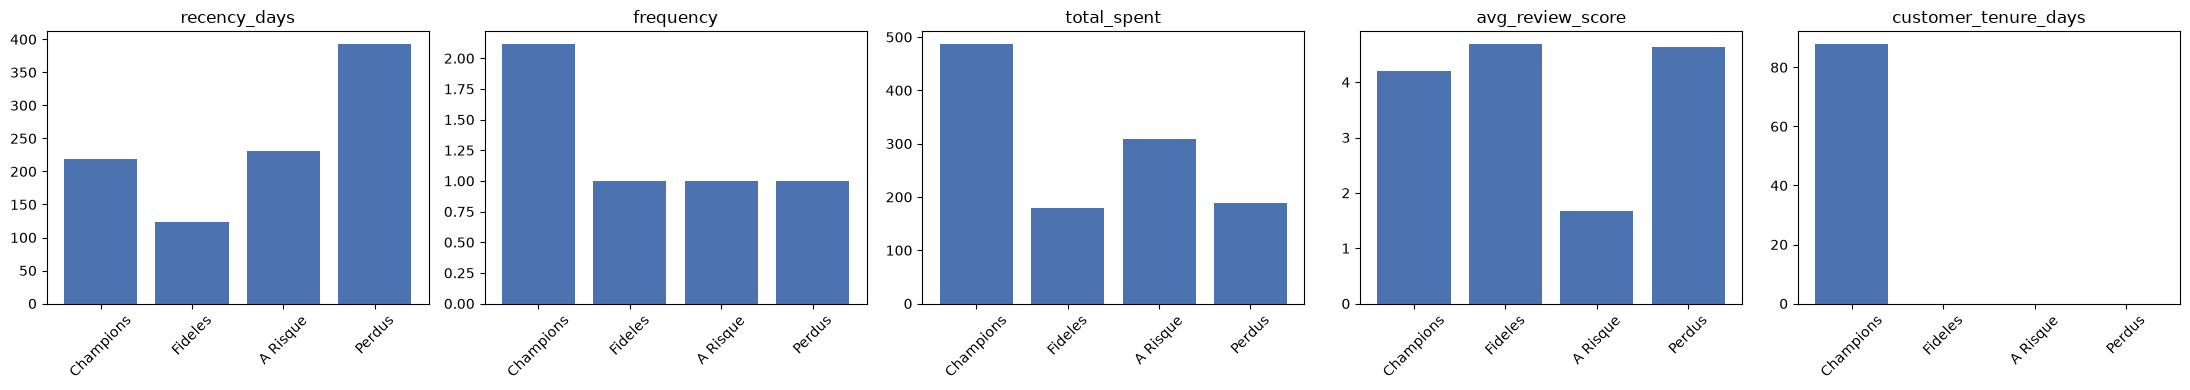

In [6]:
profile = merged_df.groupby("segment_name")[segmentation.RAW_PROFILE_FEATURES].mean()
profile = profile.reindex(segmentation.SEGMENT_NAMES_BY_RFM_RANK)

fig, axes = plt.subplots(1, len(segmentation.RAW_PROFILE_FEATURES), figsize=(22, 4))
for ax, feature in zip(axes, segmentation.RAW_PROFILE_FEATURES):
    ax.bar(profile.index, profile[feature], color=DEFAULT_COLOR)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Comparaison avec DBSCAN

In [7]:
dbscan_stats = segmentation.compare_with_dbscan(X)
dbscan_stats

[ETAPE 4] DBSCAN(eps=0.5, min_samples=5) : 19 clusters trouves, 1.30% de points bruit (label=-1)


[ETAPE 4] Silhouette score DBSCAN (hors bruit) : 0.2717
[ETAPE 4] K-Means est prefere ici comme algo principal : DBSCAN(eps=0.5, min_samples=5) produit 19 clusters de densite variable, trop nombreux et non controlables directement pour livrer 4 segments marketing actionnables (le nombre de clusters depend d'eps/min_samples, pas d'un choix explicite de k). K-Means impose k=4 directement, ce qui correspond au besoin business (Champions/Fideles/A Risque/Perdus) ; DBSCAN reste utile ici surtout pour reperer des points aberrants (bruit), pas pour segmenter toute la base.


{'n_clusters': 19,
 'noise_pct': np.float64(1.3035840527860494),
 'silhouette': 0.27174215882805924}

## 8. Clustering hierarchique sur echantillon (dendrogramme)

[ETAPE 5] AgglomerativeClustering(n_clusters=4) sur echantillon n=3000
[ETAPE 5] Adjusted Rand Score vs K-Means : 0.2917
[ETAPE 5] Dendrogramme sauvegarde dans C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\docs\dendrogram.png


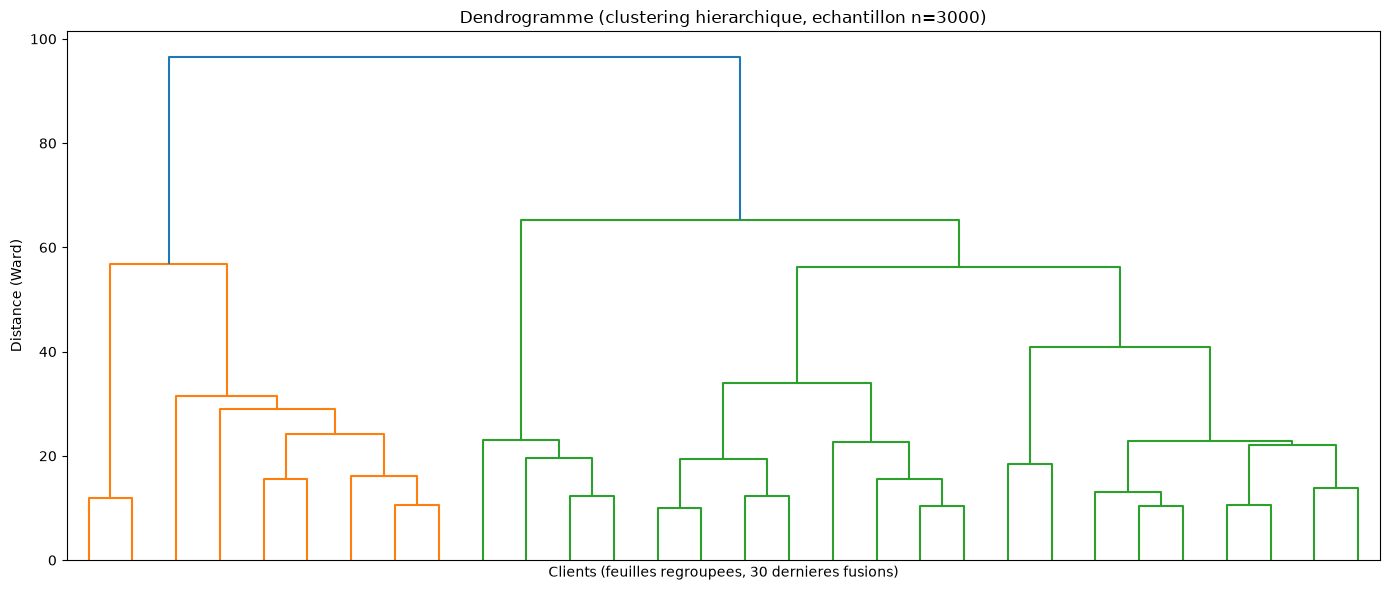

Adjusted Rand Score vs K-Means : 0.2917


In [8]:
hier_labels, hierarchical_ari, fig = segmentation.hierarchical_clustering_sample(merged_df)
plt.show()
print(f"Adjusted Rand Score vs K-Means : {hierarchical_ari:.4f}")

## 9. Conclusions

**Les 4 segments retenus (K-Means, k=4) :**
1. **Champions** (~3% des clients) : seul segment multi-acheteurs (frequency > 1), depense la plus elevee, bonne satisfaction. Ce sont les clients les plus rentables.
2. **Fideles** (~46% des clients, le plus gros segment) : acheteurs recents, tres satisfaits, mais encore a une seule commande — plus proches de "nouveaux clients prometteurs" que de fideles au sens classique.
3. **A Risque** (~16% des clients) : distingues surtout par une satisfaction tres basse (avg_review_score ~1.7), pas uniquement par la recency/frequence.
4. **Perdus** (~35% des clients) : recency la plus haute, une seule commande ancienne, inactifs depuis longtemps.

**Recommandations marketing** (detaillees dans `docs/segmentation_report.txt`) :
- Champions : fidelisation prioritaire (programme VIP, cross-sell).
- Fideles : relance ciblee pour provoquer un 2eme achat avant degradation de la recency.
- A Risque : traiter la cause de l'insatisfaction (enquete, geste commercial) avant que le client ne devienne "Perdus".
- Perdus : reactivation a faible cout ou desinvestissement selon le ROI attendu.

**Pourquoi k=4 et pas k=2 (meilleur silhouette score statistique) ?** k=2 separe surtout les clients "actifs" des "inactifs" (silhouette ~0.69 contre ~0.32 pour k=4), mais ne distingue pas les Champions des Fideles ni les segments a traiter en priorite (A Risque vs Perdus). k=4 est un choix business assume, pas un optimum statistique pur.

**Pourquoi K-Means plutot que DBSCAN comme algo principal ?** DBSCAN(eps=0.5, min_samples=5) trouve 19 clusters fragmentes (pas de k impose), utile pour reperer des points aberrants (1.3% de bruit) mais inexploitable pour un decoupage marketing a 4 segments. Le clustering hierarchique (Adjusted Rand Score ~0.29 vs K-Means) confirme qu'une structure en 4 groupes est plausible mais sensible a la methode : K-Means reste retenu pour sa rapidite sur les 93 358 clients complets et son k explicite.

**Lien avec le Prompt 7 (prediction de churn)** : les segments `A Risque` et `Perdus` regroupent deja la majorite des clients churned (recency elevee par construction), donc `segment`/`segment_name` pourront servir de feature categorielle utile au modele de churn — en gardant a l'esprit le meme risque de fuite de donnees deja identifie en Phase 5 pour `recency_days`/`R_score` : un modele qui s'appuierait uniquement sur le segment pour predire le churn n'apprendrait qu'une tautologie partielle plutot qu'un vrai signal comportemental.